# 03 - Stage 2: Remaining Useful Life (RUL) Estimation

Component C's target design tracks the Stage 1 health-score trajectory against a
(water-quality-conditioned) failure threshold to estimate "days remaining". This
prototype keeps the same input contract - engineered features **plus** the Stage 1
health score - and regresses directly against the synthetic ground-truth `RUL_days`
label using a Random Forest (`src/models/rul_estimator.py`) as a simple, dependency-light
baseline that's easy to swap for a trajectory-based model later.

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
%matplotlib inline

from src import config, data_loader, preprocessing, evaluate

from src.models.autoencoder import AnomalyAutoencoder
from src.models.rul_estimator import RULEstimator

## Rebuild Stage 1 (same as notebook 02) to get the health score input

In [2]:
variant = 'variant3'
df = data_loader.load_variant(variant)
splits = data_loader.split_by_time(df)
feature_cols = config.FEATURE_COLS[variant]

scaler = preprocessing.fit_scaler(splits['train'], feature_cols)
X_train_win, X_train_last, meta_train = preprocessing.build_windows(splits['train'], feature_cols, scaler)
X_test_win, X_test_last, meta_test = preprocessing.build_windows(splits['test'], feature_cols, scaler)

healthy_mask = (meta_train['failure_mode_label'] == 'Normal').values
autoencoder = AnomalyAutoencoder(input_dim=X_train_win.shape[1]).fit(X_train_win[healthy_mask])

health_train = autoencoder.reconstruction_error(X_train_win)
health_test = autoencoder.reconstruction_error(X_test_win)

## Train the RUL regressor
Input = scaled engineered features at the window's last timestep, **plus** the Stage 1 health score.

In [3]:
X_rul_train = np.hstack([X_train_last, health_train.reshape(-1, 1)])
y_rul_train = meta_train['RUL_days'].values
X_rul_test = np.hstack([X_test_last, health_test.reshape(-1, 1)])
y_rul_test = meta_test['RUL_days'].values

rul_model = RULEstimator().fit(X_rul_train, y_rul_train)
y_rul_pred = rul_model.predict(X_rul_test)

metrics = evaluate.rul_metrics(y_rul_test, y_rul_pred)
print(f"RMSE: {metrics['rmse']:.2f} days   MAE: {metrics['mae']:.2f} days")

RMSE: 27.50 days   MAE: 23.59 days


## Predicted vs. actual RUL over time, for a pump that actually fails

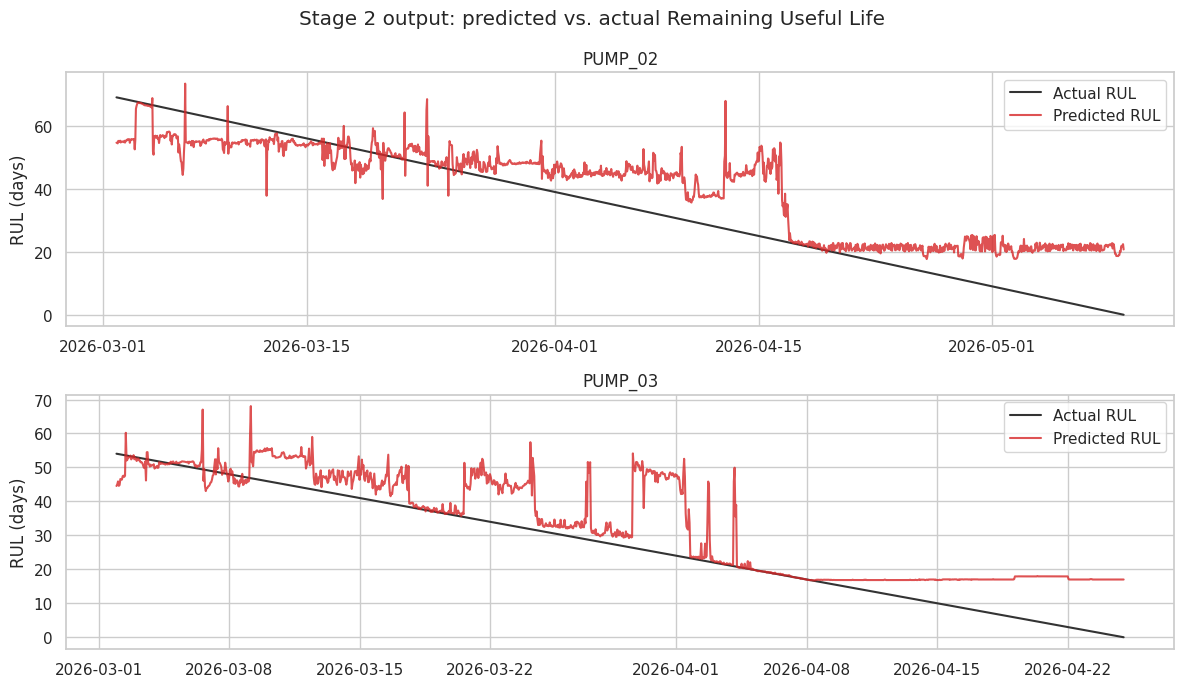

In [4]:
def score_full_pump_rul(pump_id):
    pump_df = df[df.pump_id == pump_id]
    Xw, Xl, meta = preprocessing.build_windows(pump_df, feature_cols, scaler)
    h = autoencoder.reconstruction_error(Xw)
    Xr = np.hstack([Xl, h.reshape(-1, 1)])
    meta = meta.copy()
    meta['RUL_days_predicted'] = rul_model.predict(Xr)
    return meta

fig, axes = plt.subplots(2, 1, figsize=(12, 7))
for ax, pump_id in zip(axes, ['PUMP_02', 'PUMP_03']):
    m = score_full_pump_rul(pump_id)
    ax.plot(m['timestamp'], m['RUL_days'], label='Actual RUL', color='#333333')
    ax.plot(m['timestamp'], m['RUL_days_predicted'], label='Predicted RUL', color='#d62728', alpha=0.8)
    ax.set_title(pump_id)
    ax.set_ylabel('RUL (days)')
    ax.legend()
fig.suptitle('Stage 2 output: predicted vs. actual Remaining Useful Life')
fig.tight_layout()
plt.show()

## Feature importance
Which inputs is the RUL model actually leaning on?

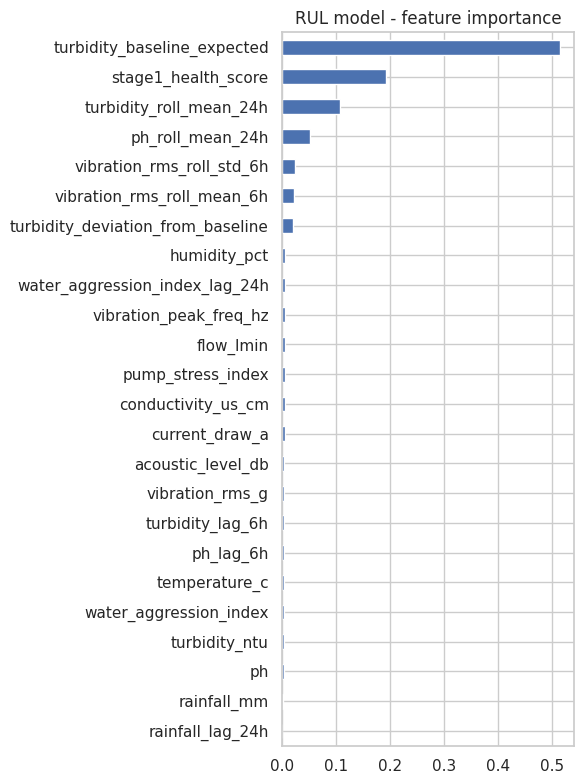

In [5]:
importances = pd.Series(
    rul_model.model.feature_importances_,
    index=feature_cols + ['stage1_health_score'],
).sort_values()
fig, ax = plt.subplots(figsize=(6, 8))
importances.plot(kind='barh', ax=ax, color='#4c72b0')
ax.set_title('RUL model - feature importance')
plt.tight_layout()
plt.show()

**Takeaway:** the Stage 1 health score and the mechanical/water-quality features it's built from carry most of the RUL signal, which is the intended design - Stage 2 leans on Stage 1's output rather than re-deriving everything from scratch. Next: `04_stage3_failure_mode_classification.ipynb`.